# DHS surface interpolation

In [1]:
import os

filepath: r'functions.py'
import functions
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import rasterio

from rasterio.features import shapes
from shapely.geometry import shape, mapping

import seaborn as sns
import matplotlib.pyplot as plt

import pickle
import shutil

%load_ext autoreload

from skgstat import Variogram

from scipy.spatial import cKDTree

### Parameters

In [2]:
#Urban surface threshold to clip out urban grids (from 0-30) on the Global Human Settlement Layer (GHSL) by the European Commission

ust = 25 # (o to 30) 0 is a totally unpopulated pixel and 30 is a totally urban pixel
target_indicator = 'rate_ckfl' #Name of the indicator form the DHS cluster data to be predicted -- SCHOOL ATTENDANCE
country = 'KHM' #Three digit country code
nis_year = 2016
year = 2014 #Year of the dhs survey in use
report = {} #Dictionary to store useful variables
#buffer_size = 10000 # In meters

In [3]:
report['Country'] = country
report['DHS survey year'] = year
report['Target Indicator'] = target_indicator
report['Urban-rural threshold'] = ust

### Preparation of Georeferenced DHS Indicator Data

In [4]:
#mpi_folder = '/Users/Daniel/Library/CloudStorage/GoogleDrive-dwiesner@sig-gis.com/.shortcut-targets-by-id/1UFnD8ofHi_4YXqnGCH4FLW8bapLdp4qX/DISES SIG/Dataset Information/MPI/'

In [4]:
data_folder_SAE=r'/data'
dhs_shape_path = f'data/underlying/sae-dhs-underlying-{year}.shp'
print(dhs_shape_path)

data/underlying/sae-dhs-underlying-2014.shp


In [5]:
#This files contains the variable equivalence between the NIS and DHS datasets. 
common_variables_path = f'data/common_variables.xlsx'
common_variables = pd.read_excel(common_variables_path)

In [6]:
common_variables.head()

,Description,DHS_code,Rate variable (methodology 4),Description.1,NIS_code,DUMMY
0,Household had child mortality under 18 in the ...,d_cm,rate_cm,Child mortality rate calculated as the proport...,523-C_MORT_RATE,536-C_MORT_DUM
1,Household has individuals malnourished,d_nutr,rate_nutr,NaN,NaN,NaN
2,Household has not all school age children up t...,d_satt,rate_satt,NaN,NaN,NaN
3,Household has less one member with 6 years of ...,d_educ,rate_educ,Illiterate population rate calculated as the p...,513-ILLITERATE_RATE,537-ILLIT_DUM
4,Household doesn't electricity,d_elct,rate_elct,Household with electricity rate calculated as ...,534-LQ_ROOF_ELEC_RATE,540-HOUSE_ELEC_DUM


In [7]:
#Load DHS data
path = dhs_shape_path 
dhs = gpd.read_file(path)
dhs = functions.exclude_zero_coordinates(dhs)
#Store the file's crs and use it as the projects
pcrs = dhs.crs

In [8]:
dhs_variables = common_variables['Rate variable (methodology 4)'][common_variables['Rate variable (methodology 4)'].notnull()].to_list()

In [10]:
print(dhs_variables)

['rate_cm', 'rate_nutr', 'rate_satt', 'rate_educ', 'rate_elct', 'rate_hsg', 'rate_wtr', 'rate_sani', 'rate_ckfl', 'rate_asst']


In [9]:
dhs_variables.append('geometry')

In [10]:
dhs = dhs[dhs_variables]

In [11]:
dhs_variables.remove('geometry')

In [12]:
report['DHS clusters before urban masking'] = dhs.shape[0]

## Selection and Preparation of Geospatial Covariate Layers

In [13]:
# Load the shape file with geographic covariates
initial_shape_path = f'data/panel-khm-02082024-v3.shp' #Geographic panel with all variables
gdf = gpd.read_file(initial_shape_path)
gdf = gdf.to_crs(pcrs)

<Axes: >

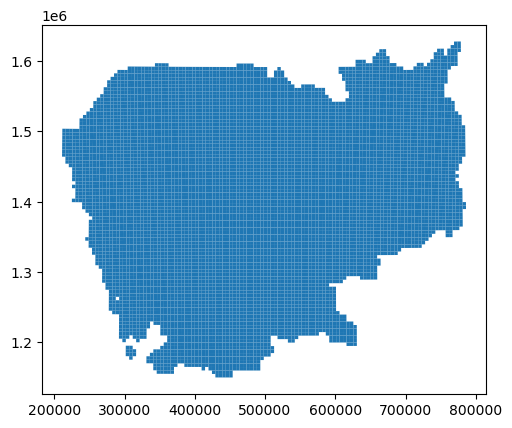

In [14]:
gdf["geometry"].plot()

In [15]:
report['Grids before masking'] = gdf.shape[0]

In [16]:
report['CRS'] = pcrs.name

### Drop urban areas

To identify urban zones we use: 

- Global Human Settlement Layer (GHSL) by the European Commission:
	•	The GHSL produces global maps of urban areas based on satellite imagery and other data.
- We are using: GHS-SMOD
- https://human-settlement.emergency.copernicus.eu/ghs_smod2023.php

In [17]:
#Paths

urban_layer_raster = "data/GHS_SMOD_E2025_GLOBE_R2023A_54009_1000_V2_0.tif"

country_bounds = 'data/country_bounds.shp'
cropped_urban_layer_raster = 'data/temp_files/urban_layer.tiff'
report_folder = 'data/temp_files/report'

#Folder for temporary files
os.makedirs('data/temp_files', exist_ok=True)
os.makedirs(report_folder, exist_ok=True)

#### Create a mask of urban areas

In [18]:
#Crop the global urban areas raster to the area of the Country of interest
functions.raster_clipping(country_bounds, urban_layer_raster, cropped_urban_layer_raster)

Reprojecting shapefile from EPSG:4326 to PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Cropped raster saved to: data/temp_files/urban_layer.tiff


'data/temp_files/urban_layer.tiff'

In [19]:
urban_mask = functions.generate_urban_mask(cropped_urban_layer_raster, ust, 'data/temp_files/urban_mask_polygons.shp')

In [20]:
#Clip the urban areas out of the main df
gdf = functions.inverted_clip_touching_gdf(gdf, urban_mask)
dhs = functions.inverted_clip_touching_gdf(dhs, urban_mask)

In [21]:
dhs["geometry"].nunique()

415

In [22]:
report['Grids after masking'] = gdf.shape[0]

In [23]:
report['DHS clusters after masking'] = dhs.shape[0]

In [24]:
#Clip out-of-boundaries DHS clusters: 
dhs = gpd.clip( dhs, gdf)

### Import NIS village-level data

In [25]:
nis = gpd.read_file(f'data/underlying/sae-nis-complete-{nis_year}.shp')
nis = nis.to_crs(pcrs)

In [26]:
#Urban areas masking
nis = functions.inverted_clip_touching_gdf(nis, urban_mask)

In [27]:
nis.columns

Index(['PHUMCODE', '523-C_MORT', '513-ILLITE', '534-LQ_ROO', '517-UNIMPR',
       '532-Sanit_', '531-AGRI_A', '521-MOB_AS', '366-KM_Hea', 'geometry'],
      dtype='object')

In [28]:
nis_columns = [col for col in nis.columns if col != "geometry"]
print(nis_columns)

['PHUMCODE', '523-C_MORT', '513-ILLITE', '534-LQ_ROO', '517-UNIMPR', '532-Sanit_', '531-AGRI_A', '521-MOB_AS', '366-KM_Hea']


In [29]:
print(nis["PHUMCODE"].nunique())
print(f"There should be", 12314-379, "observations without rate_ckfl.")

11478
There should be 11935 observations without rate_ckfl.


Nearest NIS to DHS observations: 
- The next procedure searches for the nearest NIS village per psu and, for avoiding NIS duplicates, if NIS village it's already taken, then the DHS searches for the second nearest NIS village. 
- Joins DHS information to the asign NIS village.  

In [30]:
print(dhs.crs)
print(nis.crs)

EPSG:32648
EPSG:32648


In [31]:

# Ensure both GeoDataFrames have the same CRS
dhs = dhs.to_crs(nis.crs)

# Step 1: Extract coordinates from the centroids of the geometries
nis_coords = np.array(list(nis.geometry.centroid.apply(lambda geom: (geom.x, geom.y))))
dhs_coords = np.array(list(dhs.geometry.apply(lambda geom: (geom.x, geom.y))))

# Step 2: KDTree over NIS villages
tree = cKDTree(nis_coords)

# Step 3: Search for the 5 nearest NIS neighbors per each DHS psu
_, nearest_pos_indices = tree.query(dhs_coords, k=5)

# Map positional index to real index in the NIS GeoDataFrame
nis_index_array = nis.index.to_numpy()
nearest_real_indices = nis_index_array[nearest_pos_indices]

# Step 4: Asigns unique NIS per DHS observation
assigned_nis = set()
final_assignments = []

for i in range(nearest_real_indices.shape[0]):
    assigned = False
    for j in range(nearest_real_indices.shape[1]):
        candidate = nearest_real_indices[i][j]
        if candidate not in assigned_nis:
            final_assignments.append(candidate)
            assigned_nis.add(candidate)
            assigned = True
            break
    if not assigned:
        final_assignments.append(None)  # Didn't find a unique NIS for this DHS observation

# Step 5: Save the assignments back to the DHS DataFrame
dhs['assigned_nis_idx'] = final_assignments


In [32]:
print(dhs['assigned_nis_idx'].duplicated().sum())

0


In [33]:
dhs.head()

,rate_cm,rate_nutr,rate_satt,rate_educ,rate_elct,rate_hsg,rate_wtr,rate_sani,rate_ckfl,rate_asst,geometry,assigned_nis_idx
274,0.000000,0.277778,0.055556,0.333333,0.055556,0.388889,0.055556,0.555556,1.000000,0.111111,POINT (482857.81 1168144.945),11119
273,0.000000,0.166667,0.111111,0.277778,0.166667,0.722222,0.222222,0.722222,0.722222,0.111111,POINT (487256.927 1172617.065),11059
341,0.055556,0.333333,0.111111,0.666667,1.000000,0.944444,0.500000,0.944444,0.944444,0.222222,POINT (467795.512 1173200.477),11054
272,0.000000,0.166667,0.111111,0.388889,0.000000,0.500000,0.388889,0.500000,0.833333,0.166667,POINT (487137.056 1176279.909),11036
275,0.055556,0.444444,0.111111,0.333333,0.111111,0.611111,0.444444,0.555556,1.000000,0.000000,POINT (481936.889 1187554.402),11151


In [34]:
dhs["assigned_nis_idx"].nunique() #It was successfully assigned the nearest NIS village all 378 to the DHS clusters

403

In [35]:
dhs_vars = dhs.drop(columns='geometry')
dhs_vars = dhs_vars.set_index('assigned_nis_idx')
nis = nis.join(dhs_vars, how='left')

In [36]:
nis.head()

,PHUMCODE,523-C_MORT,513-ILLITE,534-LQ_ROO,517-UNIMPR,532-Sanit_,531-AGRI_A,521-MOB_AS,366-KM_Hea,geometry,rate_cm,rate_nutr,rate_satt,rate_educ,rate_elct,rate_hsg,rate_wtr,rate_sani,rate_ckfl,rate_asst
0,1020101.0,0.0,4.287370,0.0,123.979592,34.693878,153.061224,8.574739,3.0,POINT (287393.08 1495013.949),0.0,0.25,0.0,0.117647,0.058824,0.352941,0.294118,0.470588,1.0,0.058824
1,1020102.0,0.0,0.894309,0.0,160.534125,43.620178,108.605341,27.398374,0.5,POINT (285493.095 1495013.949),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1020103.0,0.0,0.000000,0.0,121.414141,26.262626,159.797980,15.062389,0.0,POINT (285493.095 1494613.952),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1020104.0,0.0,0.343249,0.0,105.741627,45.933014,111.004785,12.013730,0.5,POINT (284493.102 1493813.959),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1020105.0,0.0,0.000000,0.0,165.217391,42.028986,61.352657,19.889503,1.2,POINT (284593.102 1494413.954),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
KHM=gpd.read_file(r"data/country_bounds.shp")
KHM = KHM.to_crs(dhs.crs)
print(KHM.crs)

EPSG:32648


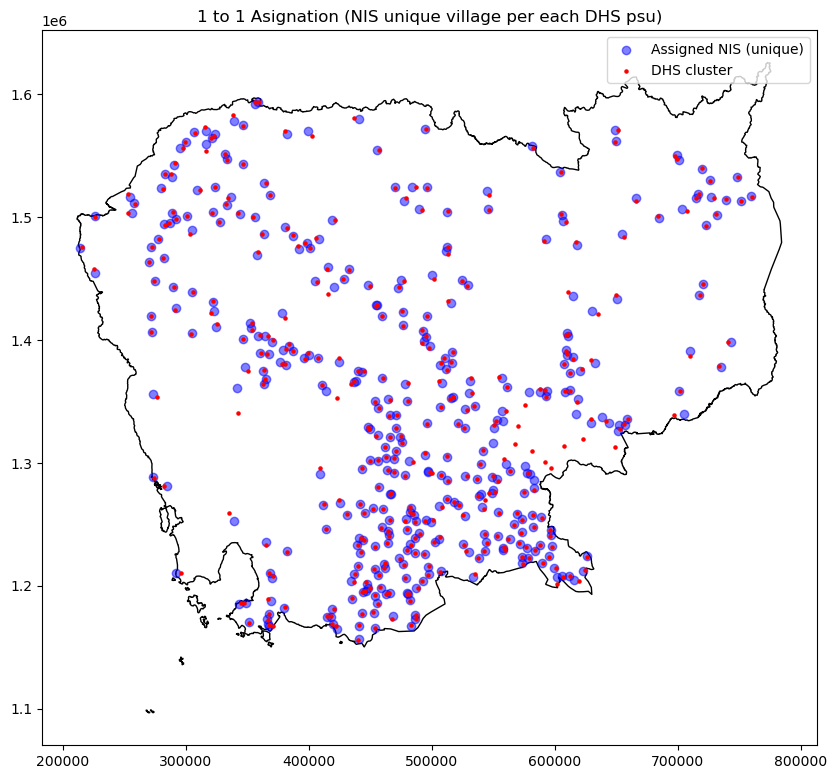

In [38]:

fig, ax = plt.subplots(figsize=(10, 10))
KHM.plot(ax=ax, color='white', edgecolor='black')
nis.boundary.plot(ax=ax, linewidth=0.3, color='lightgrey')

assigned_nis = nis.reindex(dhs['assigned_nis_idx']).copy()
dhs_points = dhs.geometry

assigned_nis.geometry.plot(ax=ax, color='blue', label='Assigned NIS (unique)', alpha=0.5)
dhs_points.plot(ax=ax, color='red', label='DHS cluster', markersize=5)

plt.legend()
plt.title("1 to 1 Asignation (NIS unique village per each DHS psu)")
plt.show()




In [39]:
nis.columns

Index(['PHUMCODE', '523-C_MORT', '513-ILLITE', '534-LQ_ROO', '517-UNIMPR',
       '532-Sanit_', '531-AGRI_A', '521-MOB_AS', '366-KM_Hea', 'geometry',
       'rate_cm', 'rate_nutr', 'rate_satt', 'rate_educ', 'rate_elct',
       'rate_hsg', 'rate_wtr', 'rate_sani', 'rate_ckfl', 'rate_asst'],
      dtype='object')

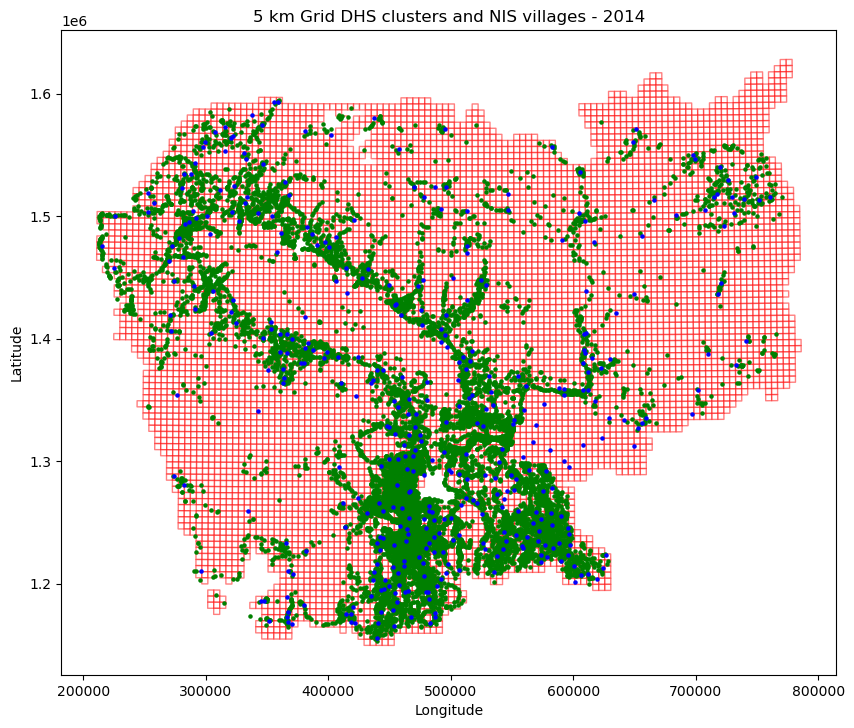

In [40]:
# Create a plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the GeoDataFrame
gdf.plot(ax=ax, facecolor='white', edgecolor='red', alpha=0.5)

# Plot the points on top
nis.plot(ax=ax, color='green', markersize=5)
dhs.plot(ax=ax, color='blue', markersize=5)

# Customize the plot (optional)
ax.set_title(f'5 km Grid DHS clusters and NIS villages - {year}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.savefig(os.path.join(report_folder, f'1. 5 km Grid DHS clusters and NIS villages - {year}.pdf'))

In [41]:

#Saved the clipped shape for later use
shape_folder = r"data\temp_files\clipped_shape"

# Check if the directory exists
if os.path.exists(shape_folder):
    # If it exists, remove the directory and all its contents
    shutil.rmtree(shape_folder)

os.mkdir(shape_folder)
gdf.to_file(os.path.join(shape_folder,'clipped_shape.shp'))


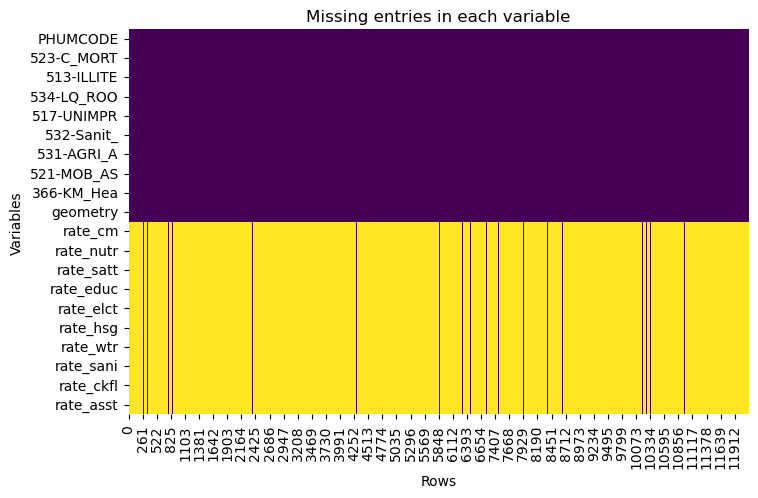

In [42]:
picture_path = os.path.join(report_folder, '2. NIS - DHS - Missing Chart.pdf')
functions.plot_missing_values_vertical(nis, picture_path)

### Merging the 3 datasets

In [43]:
print(nis.crs)
print(gdf.crs)

EPSG:32648
EPSG:32648


In [44]:
#This steps keeps only covariates on the year and -+1 year
gdf = functions.filter_columns_by_year(gdf, year)

In [45]:
gdf.describe().round(2).transpose()

,count,mean,std,min,25%,50%,75%,max
cf_binary,7695.0,0.03,0.18,0.00,0.00,0.00,0.00,1.00
cf_percent,7695.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
cf_code,7695.0,2091.36,18395.40,0.00,0.00,0.00,0.00,240208.00
pa_binary,7695.0,0.39,0.49,0.00,0.00,0.00,1.00,1.00
tcc2013,7695.0,31.70,20.24,0.00,15.00,29.00,43.00,78.00
...,...,...,...,...,...,...,...,...
n_cattle,7443.0,335.32,499.63,0.08,46.93,146.30,427.90,7124.43
ASI_10_23,4892.0,8.98,8.38,0.00,3.00,6.75,11.50,45.07
prec_10_23,7683.0,2089.81,578.94,1126.33,1656.44,2019.00,2266.90,4336.59
STme_10_23,7691.0,45580.10,1236.93,40537.44,44710.98,45779.47,46532.05,50554.21


In [46]:
# Perform spatial join to keep only villages that fall within the grid with all the geographic covariates
nis = gpd.sjoin(nis, gdf, predicate='within', how='inner')

In [47]:
nis["geometry"].nunique()

11238

In [48]:
# Show all columns in the output
import pandas as pd
pd.set_option('display.max_columns', None)

print(nis.columns.tolist())

['PHUMCODE', '523-C_MORT', '513-ILLITE', '534-LQ_ROO', '517-UNIMPR', '532-Sanit_', '531-AGRI_A', '521-MOB_AS', '366-KM_Hea', 'geometry', 'rate_cm', 'rate_nutr', 'rate_satt', 'rate_educ', 'rate_elct', 'rate_hsg', 'rate_wtr', 'rate_sani', 'rate_ckfl', 'rate_asst', 'index_right', 'cf_binary', 'cf_percent', 'cf_code', 'pa_binary', 'tcc2013', 'tcc2014', 'tcc2015', 'tcc_2013_2', 'tcc_2014_2', 'tcc_2015_2', 'lc_2013', 'lc_2014', 'lc_2015', 'elevation_', 'slope', 'eastness', 'northness', 'road_dista', 'd_forest_e', 'wealth_200', 'eco_id', 'adm_level1', 'adm_level2', 'adm_level3', 'cf_buffer3', 'cf_buffer4', 'cf_buffer5', 'y2013_prec', 'y2014_prec', 'y2015_prec', 'y2013_STme', 'y2014_STme', 'y2015_STme', 'treat_cont', 'grid_id', 'pobdens20', 'pobcount20', 'acss_mrkt', 'elevatio_1', 'dprivt', 'soil_carbn', 'treecv_13', 'treecv_22', 'tree_loss', '%tree_loss', '%trees', '%rangeland', '%water', '%crops', '%builtarea', '%baregnd', '%flood_veg', '%clouds', '%snow_ice', 'NDVI_10_23', 'NPP_10_23', 'EVI

In [49]:
nis = nis.drop('index_right', axis=1)

In [50]:
#Input infinite values with NaN
nis.replace([np.inf, -np.inf], np.nan, inplace=True)

In [51]:
nis.describe()
print(nis.columns.tolist())
print(nis['geometry'].nunique())
print(nis['PHUMCODE'].nunique())

['PHUMCODE', '523-C_MORT', '513-ILLITE', '534-LQ_ROO', '517-UNIMPR', '532-Sanit_', '531-AGRI_A', '521-MOB_AS', '366-KM_Hea', 'geometry', 'rate_cm', 'rate_nutr', 'rate_satt', 'rate_educ', 'rate_elct', 'rate_hsg', 'rate_wtr', 'rate_sani', 'rate_ckfl', 'rate_asst', 'cf_binary', 'cf_percent', 'cf_code', 'pa_binary', 'tcc2013', 'tcc2014', 'tcc2015', 'tcc_2013_2', 'tcc_2014_2', 'tcc_2015_2', 'lc_2013', 'lc_2014', 'lc_2015', 'elevation_', 'slope', 'eastness', 'northness', 'road_dista', 'd_forest_e', 'wealth_200', 'eco_id', 'adm_level1', 'adm_level2', 'adm_level3', 'cf_buffer3', 'cf_buffer4', 'cf_buffer5', 'y2013_prec', 'y2014_prec', 'y2015_prec', 'y2013_STme', 'y2014_STme', 'y2015_STme', 'treat_cont', 'grid_id', 'pobdens20', 'pobcount20', 'acss_mrkt', 'elevatio_1', 'dprivt', 'soil_carbn', 'treecv_13', 'treecv_22', 'tree_loss', '%tree_loss', '%trees', '%rangeland', '%water', '%crops', '%builtarea', '%baregnd', '%flood_veg', '%clouds', '%snow_ice', 'NDVI_10_23', 'NPP_10_23', 'EVI_10_23', 'n_duc

In [52]:
print(nis['geometry'].duplicated().sum())
# Print all duplicate rows based on the 'geometry' column
duplicates = nis[nis.duplicated(subset=['geometry'], keep=False)]
print(duplicates)

2
         PHUMCODE  523-C_MORT  513-ILLITE  534-LQ_ROO  517-UNIMPR  532-Sanit_  \
1243    2120610.0    0.000000    4.538462         0.0  122.082019   78.864353   
1853    3080807.0    0.813008    7.258065         0.0  100.000000   61.594203   
1854    3080808.0    0.000000    0.000000         0.0  100.000000   32.989691   
12183  24020216.0    0.000000    6.144578         0.0  105.291005   53.968254   

       531-AGRI_A  521-MOB_AS  366-KM_Hea                        geometry  \
1243   136.277603    5.923077        8.00  POINT (255499.314 1449107.308)   
1853     3.623188   12.298387        0.80  POINT (529916.415 1315355.348)   
1854   197.938144   11.247444        0.85  POINT (529916.415 1315355.348)   
12183   94.708995    8.674699        4.00  POINT (255499.314 1449107.308)   

       rate_cm  rate_nutr  rate_satt  rate_educ  rate_elct  rate_hsg  \
1243       NaN        NaN        NaN        NaN        NaN       NaN   
1853       NaN        NaN        NaN        NaN        NaN    

In [53]:
# Columns that we need to preserve (taking the first value)
cols_pres = ['PHUMCODE', 'grid_id']

# Columns in geometry
col_geom = 'geometry'

# Columns that must be averaged except for cols_pres and col_geom
cols_mean = [col for col in nis.columns if col not in cols_pres + [col_geom]]


In [54]:
# Group by geometry
nis_nodup = nis.groupby('geometry').agg(
    {**{col: 'mean' for col in cols_mean},  # mean ignoring NA'S
     **{col: 'first' for col in cols_pres}}  # Keeps first value
).reset_index()  # Keeping goemetry as 1 column


In [55]:
print(nis_nodup["geometry"].nunique())
print(nis_nodup["PHUMCODE"].nunique())


11238
11238


In [56]:
nis = gpd.GeoDataFrame(nis_nodup, geometry='geometry', crs=nis.crs)


In [57]:
nis.describe()

,523-C_MORT,513-ILLITE,534-LQ_ROO,517-UNIMPR,532-Sanit_,531-AGRI_A,521-MOB_AS,366-KM_Hea,rate_cm,rate_nutr,rate_satt,rate_educ,rate_elct,rate_hsg,rate_wtr,rate_sani,rate_ckfl,rate_asst,cf_binary,cf_percent,cf_code,pa_binary,tcc2013,tcc2014,tcc2015,tcc_2013_2,tcc_2014_2,tcc_2015_2,lc_2013,lc_2014,lc_2015,elevation_,slope,eastness,northness,road_dista,d_forest_e,wealth_200,eco_id,adm_level1,adm_level2,adm_level3,cf_buffer3,cf_buffer4,cf_buffer5,y2013_prec,y2014_prec,y2015_prec,y2013_STme,y2014_STme,y2015_STme,treat_cont,pobdens20,pobcount20,acss_mrkt,elevatio_1,dprivt,soil_carbn,treecv_13,treecv_22,tree_loss,%tree_loss,%trees,%rangeland,%water,%crops,%builtarea,%baregnd,%flood_veg,%clouds,%snow_ice,NDVI_10_23,NPP_10_23,EVI_10_23,n_ducks,n_pigs,n_buffals,n_chickens,n_horses,n_cattle,ASI_10_23,prec_10_23,STme_10_23,gdp_2015,PHUMCODE
count,11234.000000,11234.000000,11234.000000,11234.000000,11234.000000,11234.000000,11234.000000,11234.00000,402.000000,402.000000,402.000000,402.000000,402.000000,402.000000,402.000000,402.000000,402.000000,402.000000,11238.000000,11238.0,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11033.000000,11032.000000,11007.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11237.000000,11237.000000,11237.000000,11238.000000,11238.000000,11238.000000,9440.000000,11238.000000,11238.000000,11238.000000,11238.000000,11232.000000,11238.000000,11216.000000,11216.000000,11216.000000,11216.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.000000,11238.0,11238.000000,11237.000000,11238.000000,11206.000000,11206.000000,10832.000000,11206.000000,8948.000000,11206.000000,11127.000000,11237.000000,11238.000000,11238.000000,1.123800e+04
mean,0.080076,3.572695,0.903067,112.974185,43.016198,160.363137,14.605558,5.65063,0.022589,0.275918,0.112067,0.348202,0.570145,0.421280,0.465164,0.622420,0.932748,0.131601,0.008542,0.0,712.231447,0.048407,14.244705,13.582577,13.222282,0.662128,0.360295,0.173251,3.239192,3.228517,3.218679,36.564246,0.085869,0.167733,-0.124223,622.068431,0.945922,2.748205,286.601353,10.351308,1026.359228,102642.001068,0.108649,0.144599,0.197188,1903.803800,1682.292887,1427.600140,45824.147519,46120.088817,46892.523638,-7.443293,242.003421,5643.704122,75.965676,33.031183,74.751315,260.184405,151.088873,116.165655,-34.923218,-0.083418,6.180221,17.419415,3.789008,56.287141,14.780034,0.125969,1.418077,0.000134,0.0,0.481089,0.530615,0.308362,2722.203251,722.142153,153.614232,4457.790144,13.253720,961.653617,6.809835,1703.446572,46249.462412,19509.078735,1.045871e+07
std,0.430883,6.145253,3.462244,26.350243,27.716988,52.263026,7.266794,50.29979,0.038081,0.124684,0.108209,0.194733,0.416096,0.243595,0.329400,0.239503,0.125656,0.115679,0.092034,0.0,10908.713148,0.214635,9.431481,9.307225,9.112640,0.991021,0.889867,0.773992,0.755196,0.734981,0.726478,58.790488,0.373804,0.695782,0.687319,1106.092732,2.201042,0.489199,19.679419,6.677409,685.706891,68570.598864,0.311212,0.351711,0.397893,408.272888,389.106288,309.609544,1325.430160,1117.287029,938.188492,74.882270,231.083796,4661.832896,62.729385,56.664995,7.970304,67.029316,342.185020,266.455591,115.470231,0.148220,13.482756,20.324835,8.766459,25.003104,10.753698,0.613922,5.562866,0.003838,0.0,0.071906,0.116245,0.051419,3470.645291,758.054484,241.550640,4389.685768,35.761246,820.802413,6.818243,371.297410,772.607371,19134.755653,6.811852e+06
min,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.111111,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-3.000000,-7.000000,-7.000000,1.000000,1.000000,2.000000,0.000000,0.000000,-1.000000,-1.000000,0.387016,0.000000,1.425786,0.000000,0.000000,0.000000,0.000000,0.000000

In [58]:
#Export the merged file (DHS, NIS and geocovariates)
os.makedirs('data/output', exist_ok=True)
nis.to_file(fr"data/output/merged3_completefile_{target_indicator}_{year}.shp", driver='ESRI Shapefile')

In [59]:
nis.columns.tolist()

['geometry',
 '523-C_MORT',
 '513-ILLITE',
 '534-LQ_ROO',
 '517-UNIMPR',
 '532-Sanit_',
 '531-AGRI_A',
 '521-MOB_AS',
 '366-KM_Hea',
 'rate_cm',
 'rate_nutr',
 'rate_satt',
 'rate_educ',
 'rate_elct',
 'rate_hsg',
 'rate_wtr',
 'rate_sani',
 'rate_ckfl',
 'rate_asst',
 'cf_binary',
 'cf_percent',
 'cf_code',
 'pa_binary',
 'tcc2013',
 'tcc2014',
 'tcc2015',
 'tcc_2013_2',
 'tcc_2014_2',
 'tcc_2015_2',
 'lc_2013',
 'lc_2014',
 'lc_2015',
 'elevation_',
 'slope',
 'eastness',
 'northness',
 'road_dista',
 'd_forest_e',
 'wealth_200',
 'eco_id',
 'adm_level1',
 'adm_level2',
 'adm_level3',
 'cf_buffer3',
 'cf_buffer4',
 'cf_buffer5',
 'y2013_prec',
 'y2014_prec',
 'y2015_prec',
 'y2013_STme',
 'y2014_STme',
 'y2015_STme',
 'treat_cont',
 'pobdens20',
 'pobcount20',
 'acss_mrkt',
 'elevatio_1',
 'dprivt',
 'soil_carbn',
 'treecv_13',
 'treecv_22',
 'tree_loss',
 '%tree_loss',
 '%trees',
 '%rangeland',
 '%water',
 '%crops',
 '%builtarea',
 '%baregnd',
 '%flood_veg',
 '%clouds',
 '%snow_ice'

### Analyze missings

In [60]:
report['Covariates before filtering'] = gdf.shape[1] - 3

In [61]:
report['Covariates after filtering by -+ 1y'] = gdf.shape[1] - 3

### Dealing with missing values

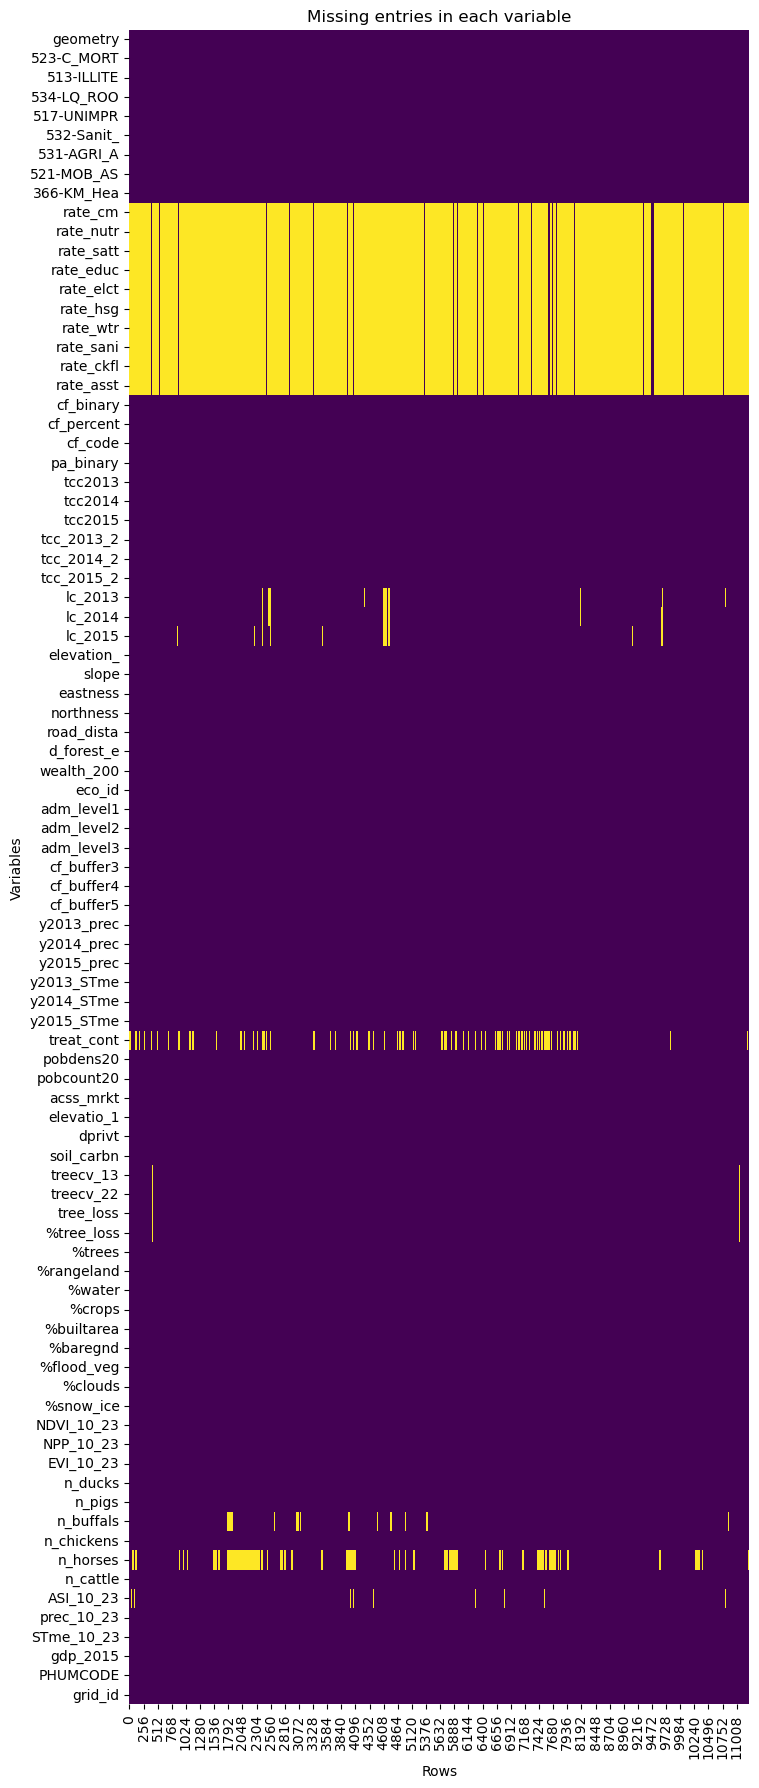

In [62]:
functions.plot_missing_values_vertical(nis)

In [63]:
nis = nis.drop(columns=['lc_2013', 'lc_2014', 'lc_2015', 'treat_cont'])

In [64]:
nis.columns.to_list()

['geometry',
 '523-C_MORT',
 '513-ILLITE',
 '534-LQ_ROO',
 '517-UNIMPR',
 '532-Sanit_',
 '531-AGRI_A',
 '521-MOB_AS',
 '366-KM_Hea',
 'rate_cm',
 'rate_nutr',
 'rate_satt',
 'rate_educ',
 'rate_elct',
 'rate_hsg',
 'rate_wtr',
 'rate_sani',
 'rate_ckfl',
 'rate_asst',
 'cf_binary',
 'cf_percent',
 'cf_code',
 'pa_binary',
 'tcc2013',
 'tcc2014',
 'tcc2015',
 'tcc_2013_2',
 'tcc_2014_2',
 'tcc_2015_2',
 'elevation_',
 'slope',
 'eastness',
 'northness',
 'road_dista',
 'd_forest_e',
 'wealth_200',
 'eco_id',
 'adm_level1',
 'adm_level2',
 'adm_level3',
 'cf_buffer3',
 'cf_buffer4',
 'cf_buffer5',
 'y2013_prec',
 'y2014_prec',
 'y2015_prec',
 'y2013_STme',
 'y2014_STme',
 'y2015_STme',
 'pobdens20',
 'pobcount20',
 'acss_mrkt',
 'elevatio_1',
 'dprivt',
 'soil_carbn',
 'treecv_13',
 'treecv_22',
 'tree_loss',
 '%tree_loss',
 '%trees',
 '%rangeland',
 '%water',
 '%crops',
 '%builtarea',
 '%baregnd',
 '%flood_veg',
 '%clouds',
 '%snow_ice',
 'NDVI_10_23',
 'NPP_10_23',
 'EVI_10_23',
 'n_du

In [65]:
columns_with_nulls = nis.columns[nis.isnull().any()].tolist()

# Remove the target variable(s) if they exist in the list
for col in dhs_variables:
    if col in columns_with_nulls:
        columns_with_nulls.remove(col)
"""
# If you want to remove the NIS variables that are not used in the model
for col in nis_columns:
    if col in columns_with_nulls:
        columns_with_nulls.remove(col)
        """

# If you also want to exclude the target_indicator:
if target_indicator in columns_with_nulls:
    columns_with_nulls.remove(target_indicator)


In [66]:
#We perform simple interpolation of null values to keep going, but the input data should not have any. 
for column in columns_with_nulls: 
    # Perform IDW interpolation to replace null values
    nis = functions.idw_interpolation(nis, column)
    #nis[column] = nis[column].fillna(0)

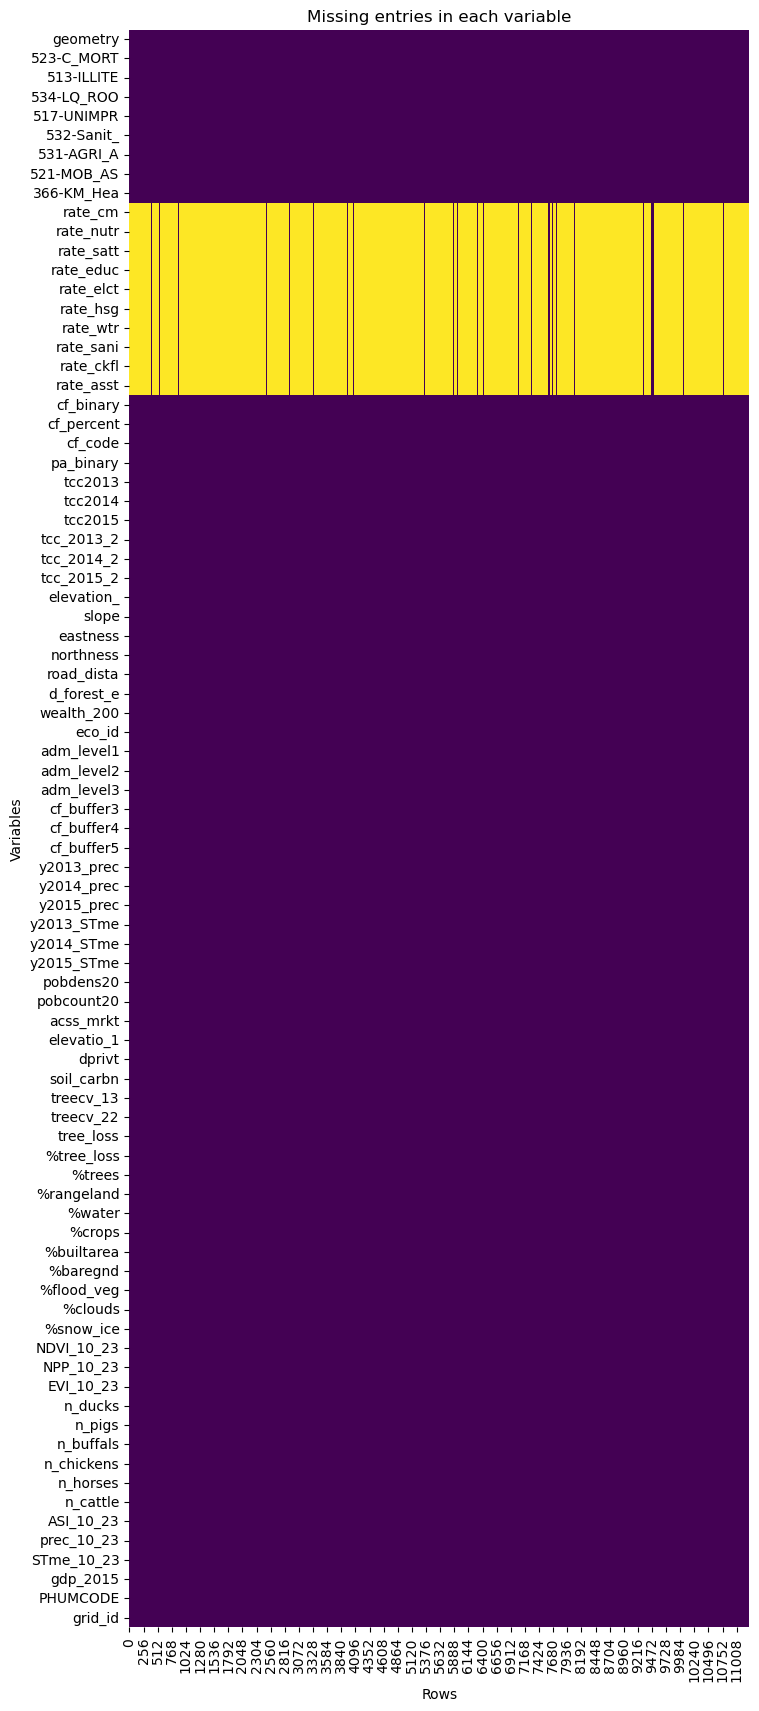

In [67]:
functions.plot_missing_values_vertical(nis)

In [68]:
# Variables to remove from gdf
dhs_variables = [
    "rate_cm",
    "rate_nutr",
    "rate_satt",
    "rate_educ",
    "rate_elct",
    "rate_hsg",
    "rate_wtr",
    "rate_sani",
    "rate_ckfl",
    "rate_asst"
]

In [69]:
#Remove all dhs_variables except the target variable for they cannot be used in the prediction
vars_to_remove = [col for col in dhs_variables if col != target_indicator]
nis = nis.drop(columns=vars_to_remove)

## Exploratory Analysis of target indicator

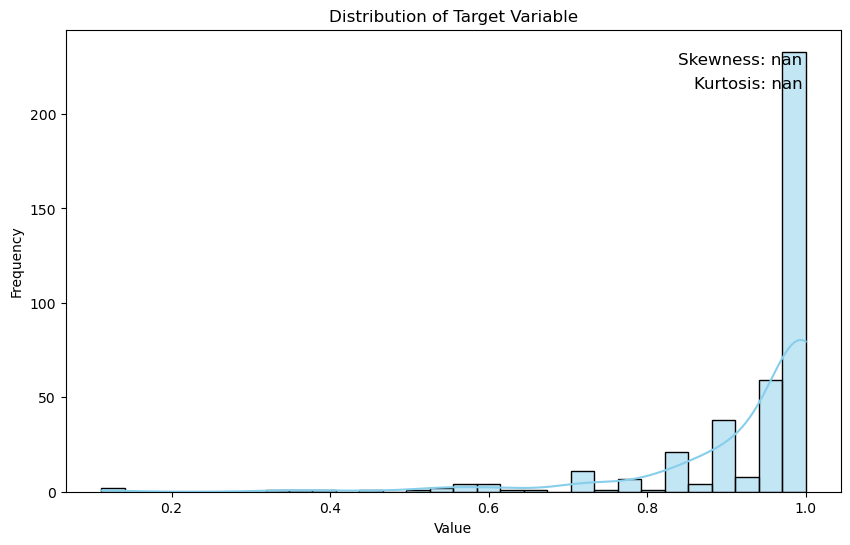

In [70]:
#There are many observations that are close to 0 in the MPI estimation.
picture_path = os.path.join(report_folder, '3. Target Distribution Before Transform.pdf')
functions.plot_distribution_with_statistics(nis[target_indicator], picture_path)

In [71]:
t2 = nis[target_indicator].describe()

In [72]:
t2 = pd.DataFrame(t2).reset_index()

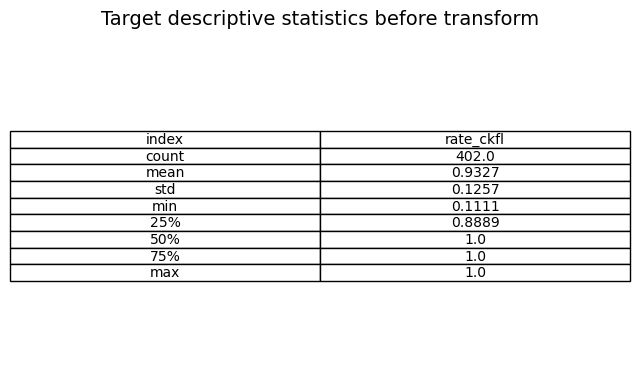

In [73]:
# Plot the DataFrame
table_path = os.path.join(report_folder, '5. Target descriptive before transform.pdf')
title = 'Target descriptive statistics before transform'
functions.df_to_pdf(t2.round(4), table_path, title=title,  show=True)

### Varioagram for the target variable

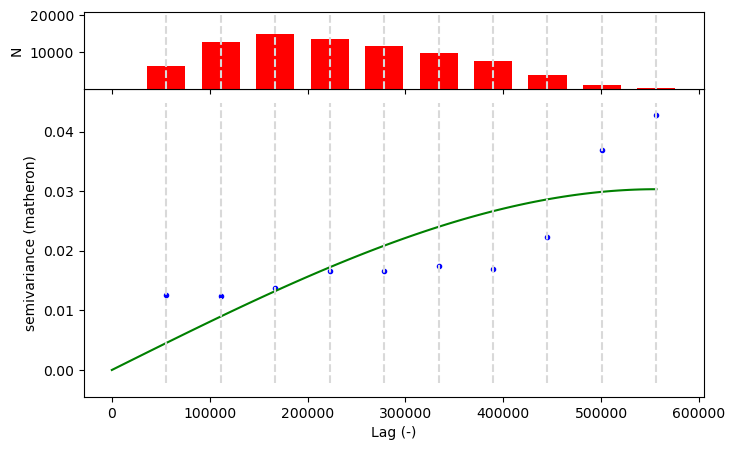

In [74]:
# Extract coordinates from the geometry column
coordinates = [(point.x, point.y) for point in dhs.geometry]
values = dhs[target_indicator].values

# Create and plot the variogram
variogram = Variogram(coordinates, values)
variogram.plot()

picture_path = os.path.join(report_folder, '4. Target Varioagram.pdf')
plt.savefig(picture_path)
plt.show()

### Set range value

In [75]:
# Automatically determine the range where the variogram levels off (from the model)
range_value = variogram.parameters[1]  # Extract the range from the fitted variogram model
print(range_value)

report['Variogram Range'] = np.sqrt(range_value) #The variance is in squared unites of the target indicator, so we take the sqrt.

0.030326748585124477


Interpretation of the Variogram:

A variogram describes the spatial continuity or spatial dependence of a variable. Interpretation:

    X-axis (Lag Distance):
        Represents the distance (lag) between pairs of points.
        The distance is normalized in this plot, indicated by "Lag (-)".

    Y-axis (Semivariance):
        Represents the semivariance, which measures the dissimilarity between values as a function of the lag distance.
        The semivariance typically increases with lag distance up to a certain point and then levels off.

    Empirical Semivariance Points (Blue Circles):
        Each blue circle represents the empirical semivariance for a specific lag distance.
        Calculated from the data by averaging the squared differences between all pairs of values separated by that lag distance.

    Fitted Variogram Model (Green Line):
        A model is fitted to the empirical semivariance points.
        The green line represents the theoretical variogram model that best fits the empirical data.

    Histogram of Pair Counts (Red Bars):
        The histogram at the top of the plot shows the number of point pairs used to calculate the semivariance at each lag distance.
        Provides information on the sample size for each lag, with higher bars indicating more pairs.

### Ls Beta suggestion

- Rapid correlation decay: If the correlation decays quickly (i.e., points that are relatively close to each other have low correlations), you might prefer a smaller length scale (ls). This means choosing a smaller beta in your HalfCauchy prior (e.g., beta=0.5 or beta=0.1).
- Slow correlation decay: If the correlation decays slowly (i.e., points remain correlated over longer distances), you may want a larger beta to allow for larger length scales (e.g., beta=2.0 or higher).

In [76]:
#Define a reasonable beta based on how quickly spatial correlation decays 
report['Suggested ls beta'] = functions.estimate_reasonable_beta(coordinates, values)

Min distance: 1194.2595096749574
Max distance: 556479.74255493
Mean distance: 204463.71068005078
Estimated range from variogram: 556479.7425418302
Long-range correlation detected. Setting beta to 2.0.


## Covariate Selection

- We replace the original selection with a Lasso model.
- "The goal was also to identify some variables that were likely to have strong statistical relationships with background environmental factors" (SAR 11) 

### Generate Square and Square-Root Transforms of Covariates

In [79]:
#Two new versions of each of the original 17 covariates were generated: a square and square-root transform yielding 17×3 = 51 candidate covariates. 
# Is this necesary or is it enough to just use Lasso to filter out un necessary variables?

In [77]:
nis.columns.tolist()

['geometry',
 '523-C_MORT',
 '513-ILLITE',
 '534-LQ_ROO',
 '517-UNIMPR',
 '532-Sanit_',
 '531-AGRI_A',
 '521-MOB_AS',
 '366-KM_Hea',
 'rate_ckfl',
 'cf_binary',
 'cf_percent',
 'cf_code',
 'pa_binary',
 'tcc2013',
 'tcc2014',
 'tcc2015',
 'tcc_2013_2',
 'tcc_2014_2',
 'tcc_2015_2',
 'elevation_',
 'slope',
 'eastness',
 'northness',
 'road_dista',
 'd_forest_e',
 'wealth_200',
 'eco_id',
 'adm_level1',
 'adm_level2',
 'adm_level3',
 'cf_buffer3',
 'cf_buffer4',
 'cf_buffer5',
 'y2013_prec',
 'y2014_prec',
 'y2015_prec',
 'y2013_STme',
 'y2014_STme',
 'y2015_STme',
 'pobdens20',
 'pobcount20',
 'acss_mrkt',
 'elevatio_1',
 'dprivt',
 'soil_carbn',
 'treecv_13',
 'treecv_22',
 'tree_loss',
 '%tree_loss',
 '%trees',
 '%rangeland',
 '%water',
 '%crops',
 '%builtarea',
 '%baregnd',
 '%flood_veg',
 '%clouds',
 '%snow_ice',
 'NDVI_10_23',
 'NPP_10_23',
 'EVI_10_23',
 'n_ducks',
 'n_pigs',
 'n_buffals',
 'n_chickens',
 'n_horses',
 'n_cattle',
 'ASI_10_23',
 'prec_10_23',
 'STme_10_23',
 'gdp_

In [78]:
#Exclude non-covariate columns
excluded =['geometry', target_indicator,"grid_id", 'PHUMCODE']

In [79]:
nis1 = nis.copy(deep=True)

In [80]:
nis.columns.to_list()

['geometry',
 '523-C_MORT',
 '513-ILLITE',
 '534-LQ_ROO',
 '517-UNIMPR',
 '532-Sanit_',
 '531-AGRI_A',
 '521-MOB_AS',
 '366-KM_Hea',
 'rate_ckfl',
 'cf_binary',
 'cf_percent',
 'cf_code',
 'pa_binary',
 'tcc2013',
 'tcc2014',
 'tcc2015',
 'tcc_2013_2',
 'tcc_2014_2',
 'tcc_2015_2',
 'elevation_',
 'slope',
 'eastness',
 'northness',
 'road_dista',
 'd_forest_e',
 'wealth_200',
 'eco_id',
 'adm_level1',
 'adm_level2',
 'adm_level3',
 'cf_buffer3',
 'cf_buffer4',
 'cf_buffer5',
 'y2013_prec',
 'y2014_prec',
 'y2015_prec',
 'y2013_STme',
 'y2014_STme',
 'y2015_STme',
 'pobdens20',
 'pobcount20',
 'acss_mrkt',
 'elevatio_1',
 'dprivt',
 'soil_carbn',
 'treecv_13',
 'treecv_22',
 'tree_loss',
 '%tree_loss',
 '%trees',
 '%rangeland',
 '%water',
 '%crops',
 '%builtarea',
 '%baregnd',
 '%flood_veg',
 '%clouds',
 '%snow_ice',
 'NDVI_10_23',
 'NPP_10_23',
 'EVI_10_23',
 'n_ducks',
 'n_pigs',
 'n_buffals',
 'n_chickens',
 'n_horses',
 'n_cattle',
 'ASI_10_23',
 'prec_10_23',
 'STme_10_23',
 'gdp_

In [81]:
# Drop the selected columns
nis1 = nis1.drop(columns=[
    target_indicator,
    'geometry', 
    'grid_id', 
    'adm_level1', 
    'adm_level2', 
    'adm_level3', 
    'cf_code', 
    'PHUMCODE', 
])

#dhs_variables.remove(target_indicator)
# Drop the selected columns
#nis1 = nis1.drop(columns=dhs_variables)

In [82]:
nis1.columns.to_list()

['523-C_MORT',
 '513-ILLITE',
 '534-LQ_ROO',
 '517-UNIMPR',
 '532-Sanit_',
 '531-AGRI_A',
 '521-MOB_AS',
 '366-KM_Hea',
 'cf_binary',
 'cf_percent',
 'pa_binary',
 'tcc2013',
 'tcc2014',
 'tcc2015',
 'tcc_2013_2',
 'tcc_2014_2',
 'tcc_2015_2',
 'elevation_',
 'slope',
 'eastness',
 'northness',
 'road_dista',
 'd_forest_e',
 'wealth_200',
 'eco_id',
 'cf_buffer3',
 'cf_buffer4',
 'cf_buffer5',
 'y2013_prec',
 'y2014_prec',
 'y2015_prec',
 'y2013_STme',
 'y2014_STme',
 'y2015_STme',
 'pobdens20',
 'pobcount20',
 'acss_mrkt',
 'elevatio_1',
 'dprivt',
 'soil_carbn',
 'treecv_13',
 'treecv_22',
 'tree_loss',
 '%tree_loss',
 '%trees',
 '%rangeland',
 '%water',
 '%crops',
 '%builtarea',
 '%baregnd',
 '%flood_veg',
 '%clouds',
 '%snow_ice',
 'NDVI_10_23',
 'NPP_10_23',
 'EVI_10_23',
 'n_ducks',
 'n_pigs',
 'n_buffals',
 'n_chickens',
 'n_horses',
 'n_cattle',
 'ASI_10_23',
 'prec_10_23',
 'STme_10_23',
 'gdp_2015']

In [83]:
#Apply transformation to covariates
nis1 = functions.auto_transform(nis1)

In [87]:
# # Generate square and square-root transforms
# squared_covariates = nis1**2
# sqrt_covariates = np.sqrt(nis1)

# # Combine all covariates into a single DataFrame
# nis2 = pd.concat([nis1, squared_covariates, sqrt_covariates], axis=1)
# nis2.columns = [f'{col}_orig' for col in nis1.columns] + \
#                         [f'{col}_squared' for col in nis1.columns] + \
#                         [f'{col}_sqrt' for col in nis1.columns]

In [84]:
nis2 = nis1.copy(deep=True)

In [85]:
#Drop the variables that generated missing values
nis2 = nis2.dropna(axis=1, how='any')

In [86]:
report['Covariates after square and square-root transforms'] = nis2.shape[1]

### Generate pair-wise interactions between covariates

In [87]:
from itertools import combinations

In [88]:
# Generate all pair-wise interaction terms and collect them in a dictionary

interaction_terms = {}
for (col1, col2) in combinations(nis2.columns, 2):
    interaction_terms[f'{col1}_x_{col2}'] = nis2[col1] * nis2[col2]

# Convert the dictionary to a DataFrame and concatenate with the original covariates
interaction_terms_df = pd.DataFrame(interaction_terms)

# Combine the covariates with the interaction terms
nis3 = pd.concat([nis2, interaction_terms_df], axis=1)


In [89]:
report['Covariates after pairwise interactions'] = nis3.shape[1]

In [90]:
#This avoids the pairwise interactions to reduce dimensionality
nis3 = nis2.copy(deep=True)

In [91]:
nis3.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['523-C_MORT', '513-ILLITE', '534-LQ_ROO', '517-UNIMPR', '532-Sanit_',
       '531-AGRI_A', '521-MOB_AS', '366-KM_Hea', 'cf_binary', 'cf_percent',
       'pa_binary', 'tcc2013', 'tcc2014', 'tcc2015', 'tcc_2013_2',
       'tcc_2014_2', 'tcc_2015_2', 'elevation_', 'slope', 'eastness',
       'northness', 'road_dista', 'd_forest_e', 'wealth_200', 'eco_id',
       'cf_buffer3', 'cf_buffer4', 'cf_buffer5', 'y2013_prec', 'y2014_prec',
       'y2015_prec', 'y2013_STme', 'y2014_STme', 'y2015_STme', 'pobdens20',
       'pobcount20', 'acss_mrkt', 'elevatio_1', 'dprivt', 'soil_carbn',
       'treecv_13', 'treecv_22', 'tree_loss', '%tree_loss', '%trees',
       '%rangeland', '%water', '%crops', '%builtarea', '%baregnd',
       '%flood_veg', '%clouds', '%snow_ice', 'NDVI_10_23', 'NPP_10_23',
       'EVI_10_23', 'n_ducks', 'n_pigs', 'n_buffals', 'n_chickens', 'n_horses',
       'n_cattle', 'ASI_10_23', 'prec_10_23', 'STme_10_23', 'gdp_2015'],
      dtype='

### Covariates selection

### Lasso

By using Lasso regression, we can directly perform feature selection and build the multivariate model in a single step, thus simplifying the process significantly:

-   Fit Lasso model to select features and build the model (Steps 2, 4, and 5 combined)

This approach leverages Lasso's ability to handle feature selection and regularization, saving time and computational effort while ensuring an interpretable and efficient model.

In [92]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.metrics import r2_score
from scipy.stats import skew, kurtosis, boxcox

In [93]:
nis4 = nis[[target_indicator]].merge(nis3, left_index=True, right_index=True, how='right')

In [94]:
#Keep only the observations that have a valid  cluster observation
nis4 = nis4[~nis4[target_indicator].isnull()]

In [95]:
y = nis4[[target_indicator]]

In [96]:
report['Target mean pre transform'] = y.values.mean()
report['Target std pre transform'] = y.values.std()

### Select the best transformation

We use Skwedness and Kurtosis criteria to select the best techinque. Strategy for Selection:

-   High Positive Skew: Apply log or square root transformation.
-   High Negative Skew: Apply square transformation (squaring the data can sometimes help with negative skew).
-   Moderate Skew: Apply Box-Cox or Yeo-Johnson transformation.
-   Low Skew and Kurtosis: No transformation or minimal transformation.

In [97]:
# Select and apply the best transformation
target_transformed, transform, lmda = functions.select_transformation(y)

#Store important information for reversion

report['Transformation Applied'] = transform #Transformation applied to target

report['Lambda'] = lmda #Store lambda variable for some reversion processes

Skewness: -3.145056876708649, Kurtosis: 12.615861282532675
Applying square transformation due to high negative skewness.


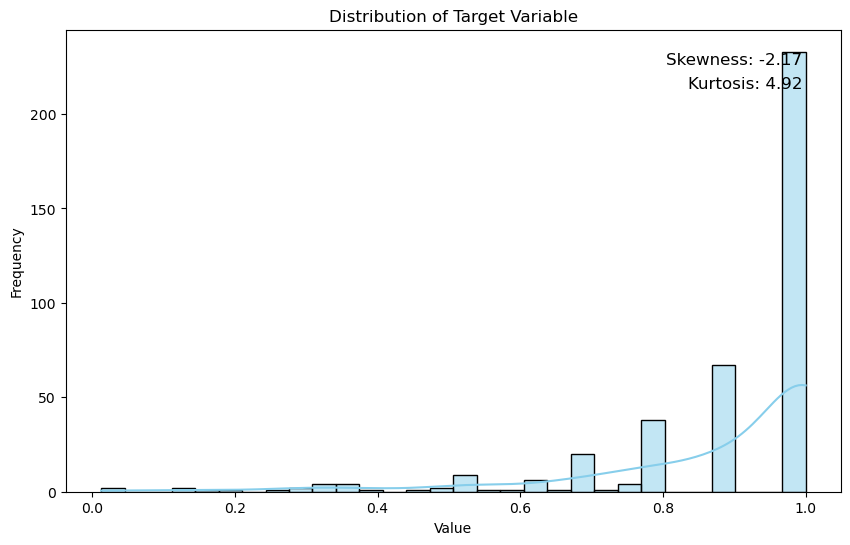

In [98]:
picture_path = os.path.join(report_folder, '6. Target transformed.png')
functions.plot_distribution_with_statistics(pd.Series(target_transformed[target_indicator]), picture_path)

In [99]:
t3 = target_transformed.describe()

In [100]:
t3 = pd.DataFrame(t3).reset_index()

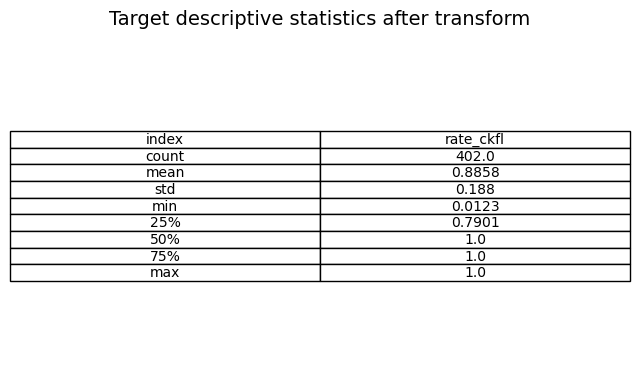

In [101]:
# Plot the DataFrame
table_path = os.path.join(report_folder, '7. Target descriptive after transform.pdf')
title = 'Target descriptive statistics after transform'
functions.df_to_pdf(t3.round(4), table_path, title=title,  show=True)

### Transform covariates

### Select covariates

In [102]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# Suppress all warnings
import warnings
warnings.filterwarnings('ignore')

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(nis4.drop([target_indicator, ], axis=1), target_transformed, test_size=0.2, random_state=42)

# Normalize the features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Normalize the target variable
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# Fit Lasso model with cross-validation to find the best alpha
# Provide a wider alpha grid with higher regularization
alphas = np.logspace(-5, 1, 100)  # from 0.0001 to ~3.16
lasso = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000).fit(X_train_scaled, y_train_scaled)

#lasso = LassoCV(cv=5, random_state=42, max_iter=1000).fit(X_train_scaled, y_train_scaled)

# Get the selected features (non-zero coefficients)
selected_features = X_train.columns[(lasso.coef_ != 0)]

In [107]:
# from sklearn.linear_model import ElasticNetCV

# X_train, X_test, y_train, y_test = train_test_split(nis4.drop([target_indicator, ], axis=1), target_transformed, test_size=0.2, random_state=42)

# enet = ElasticNetCV(
#     l1_ratio=[0.2, 0.4, 0.6, 0.8],   # blend L1 and L2 penalties
#     alphas=np.logspace(-5, 1, 100),
#     cv=5,
#     max_iter=10000
# ).fit(X_train_scaled, y_train_scaled)

# selected_features = X_train.columns[(enet.coef_ != 0)]
# print("Selected features:", selected_features.tolist())

In [103]:
print(f'{selected_features.shape[0]} variables were selected as covariates to pass on to the Bayesian model.')

38 variables were selected as covariates to pass on to the Bayesian model.


In [104]:
report['Number of covariates selected after Lasso'] = selected_features.shape[0]

In [110]:
#Generate the final df with the mpi for export
#gdf4 = pd.concat([gdf[[target_indicator, 'geometry', 'grid_id']], gdf3[selected_features]], axis = 1)

In [105]:
nis4 = nis[[target_indicator, 'geometry', 'grid_id']].merge(nis3[selected_features], left_index=True, right_index=True, how='right')

In [106]:
nis4 = nis4[nis4['geometry'].notnull()]

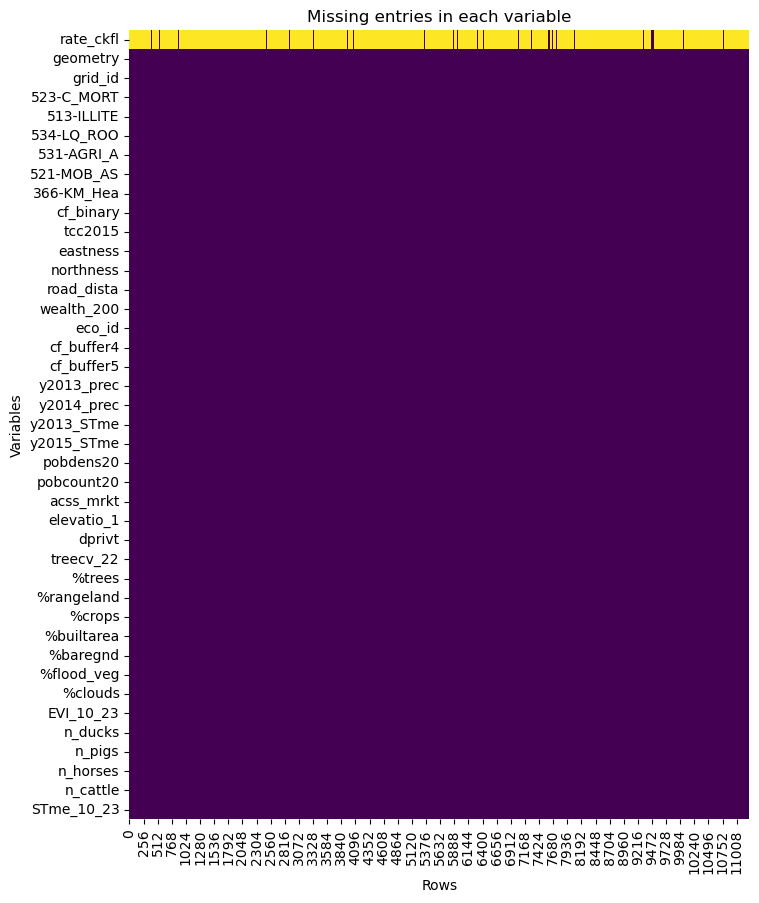

In [107]:
functions.plot_missing_values_vertical(nis4)

In [108]:
picture_path = os.path.join(report_folder,'8. Final database chart.png')

## Transforming New Covariates data

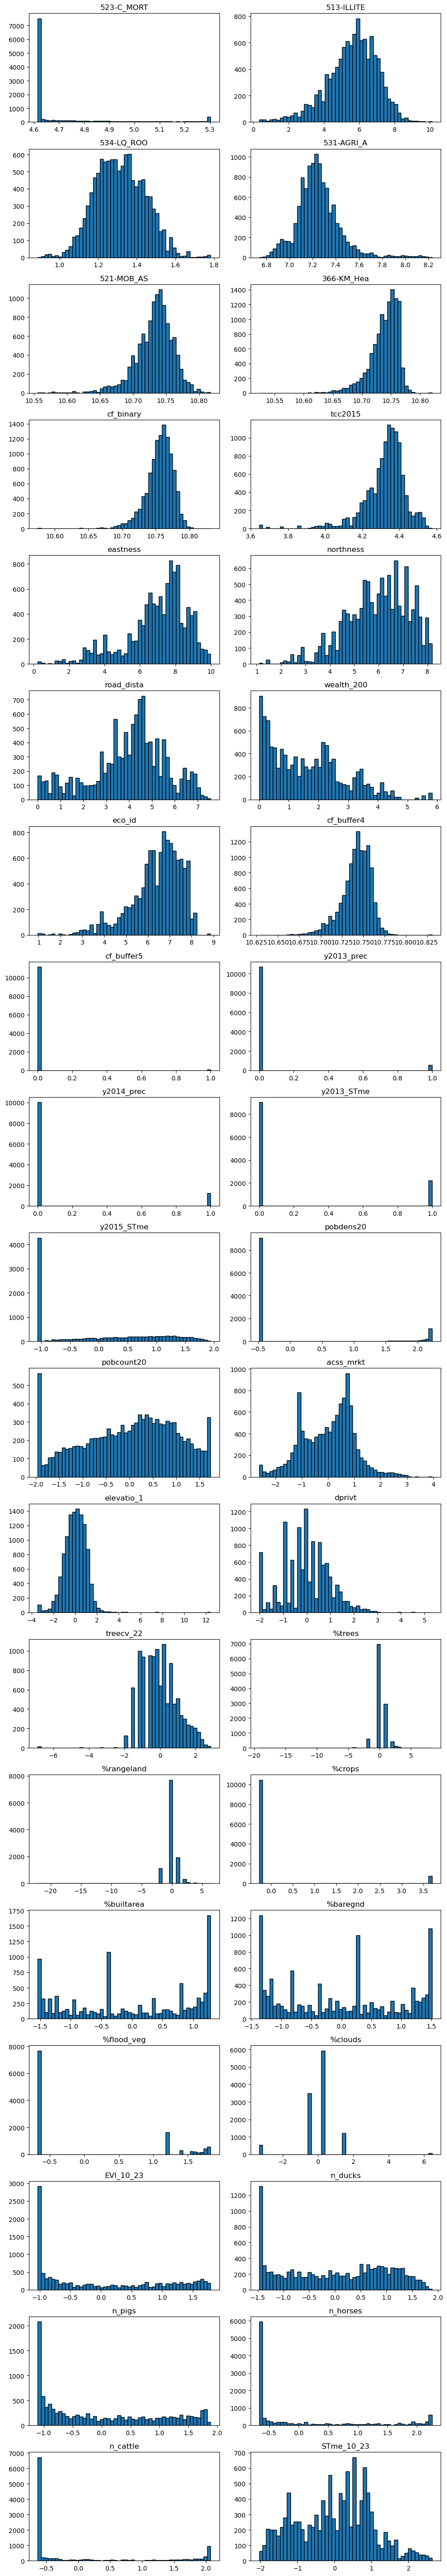

In [109]:
# Visualize distributions of covariates
functions.plot_histograms(nis4[selected_features], bins=50)

### Save objects for MBG

In [116]:
#sample_size = int(gdf4.shape[0]*0.80)

In [117]:
#Temporarily reduce dimensionality 
#gdf4 = gdf4.sample(sample_size)

In [118]:
#Save the df with selected features and with target variable
#gdf4.to_pickle('temp_files/selected_features.pkl')

In [110]:
nis4.shape

(11238, 41)

In [111]:
nis4['rate_ckfl'].notnull().sum()

np.int64(402)

In [121]:
12076-378

11698

In [112]:
nis4.columns.tolist()

['rate_ckfl',
 'geometry',
 'grid_id',
 '523-C_MORT',
 '513-ILLITE',
 '534-LQ_ROO',
 '531-AGRI_A',
 '521-MOB_AS',
 '366-KM_Hea',
 'cf_binary',
 'tcc2015',
 'eastness',
 'northness',
 'road_dista',
 'wealth_200',
 'eco_id',
 'cf_buffer4',
 'cf_buffer5',
 'y2013_prec',
 'y2014_prec',
 'y2013_STme',
 'y2015_STme',
 'pobdens20',
 'pobcount20',
 'acss_mrkt',
 'elevatio_1',
 'dprivt',
 'treecv_22',
 '%trees',
 '%rangeland',
 '%crops',
 '%builtarea',
 '%baregnd',
 '%flood_veg',
 '%clouds',
 'EVI_10_23',
 'n_ducks',
 'n_pigs',
 'n_horses',
 'n_cattle',
 'STme_10_23']

In [113]:
print(nis4["geometry"].nunique()) #Theres 1 duplicate geometry in the dataset (with diferent PHUMCODE), so we will will apply an average of the values of the duplicated geometry
print(nis4["grid_id"].nunique())

11238
2612


In [114]:
# Print all duplicate rows based on the 'geometry' column
duplicates_nis4 = nis4[nis4.duplicated(subset=['geometry'], keep=False)]
print(duplicates_nis4)

Empty GeoDataFrame
Columns: [rate_ckfl, geometry, grid_id, 523-C_MORT, 513-ILLITE, 534-LQ_ROO, 531-AGRI_A, 521-MOB_AS, 366-KM_Hea, cf_binary, tcc2015, eastness, northness, road_dista, wealth_200, eco_id, cf_buffer4, cf_buffer5, y2013_prec, y2014_prec, y2013_STme, y2015_STme, pobdens20, pobcount20, acss_mrkt, elevatio_1, dprivt, treecv_22, %trees, %rangeland, %crops, %builtarea, %baregnd, %flood_veg, %clouds, EVI_10_23, n_ducks, n_pigs, n_horses, n_cattle, STme_10_23]
Index: []


In [115]:
print(nis4["geometry"].nunique())
print(nis4["grid_id"].nunique())

11238
2612


In [116]:
print(type(nis4)) 

<class 'geopandas.geodataframe.GeoDataFrame'>


In [117]:
#Save the df with selected features and with target variable
nis4.to_pickle('data/temp_files/selected_features_full.pkl')

In [118]:
t4 = pd.DataFrame(data={'Data':report.keys(), 
                  'Value': report.values()}, 
             columns=['Data','Value'])

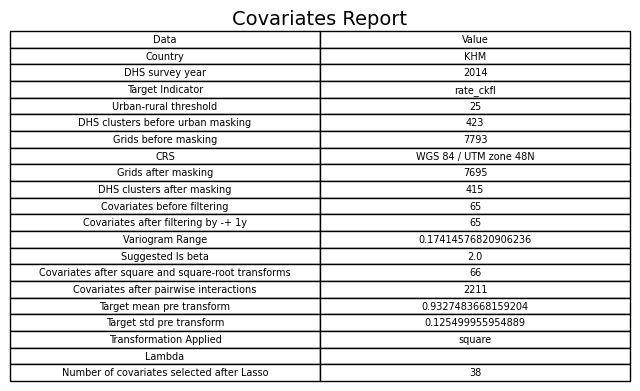

In [119]:
table_path = os.path.join(report_folder, '8. Covariates Report.pdf')
title = 'Covariates Report'
functions.df_to_pdf(t4, table_path, title=title, show=True)

In [120]:
#Save report as pickle
with open('data/temp_files/report/report.pkl', 'wb') as pickle_file:
    pickle.dump(report, pickle_file)

In [121]:
nis4.shape

(11238, 41)